
# Multilinear Regression — Physical Model (GFDL-CM4)

This notebook mirrors `notebooks/multilinear_analysis.ipynb` but runs the analysis on the aggregated physical model grid produced from GFDL-CM4 NetCDF files.

Features used:
- **Climatological features**: temperature (tas), humidity (hurs), surface wind (sfcWind), sea ice concentration (siconc)
- **Mask features**: Land/Ocean/LandIce classification mask
- **Target**: Climate change slope (pattern-scaling coefficient)

Make sure to run `physical/create_toggle_world_climate_map.py` (or have `output/physical_model_grid_5x5.csv`) available before running this notebook.


In [23]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
from pathlib import Path

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [24]:
# Configuration: File Paths (physical model grid)
REGRIDDED_DATA_CSV = '../output/physical_model_grid_5x5.csv'
OUTPUT_DIR = './notebook_outputs/multilinear_physical'
PREDICTIONS_CSV = os.path.join(OUTPUT_DIR, 'predictions_physical.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Input file: {REGRIDDED_DATA_CSV}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Predictions CSV: {PREDICTIONS_CSV}")

Input file: ../output/physical_model_grid_5x5.csv
Output directory: ./notebook_outputs/multilinear_physical
Predictions CSV: ./notebook_outputs/multilinear_physical/predictions_physical.csv



## Data Loading & Exploration (Physical Grid)

Load the aggregated physical model grid CSV produced by `create_toggle_world_climate_map.py`, along with additional climatological features from GFDL-CM4 NetCDF files. The dataframe will contain:
- `climo_temp`: Climatological near-surface air temperature
- `climo_humidity`: Climatological relative humidity
- `climo_wind`: Climatological surface wind speed (proxy for ocean upwelling)
- `climo_seaice`: Climatological sea ice concentration (% of grid cell)
- `land_ocean_ice_mask`: Land/Ocean/Land-Ice classification (1=Land, 2=Ocean, 3=Land Ice)
- `slope`: Climate change pattern-scaling coefficient (target variable)


In [43]:
# Extract features
print("\nExtracting variables...")
mask_df = extract_netcdf_feature(landoceanice_ds, 'MASK', 'land_ocean_ice_mask')
if mask_df is not None:
    print(f"  Land/Ocean/LandIce mask: {len(mask_df)} gridpoints")

wind_df = extract_netcdf_feature(wind_ds, 'sfcWind', 'climo_wind')
if wind_df is not None:
    print(f"  Wind climatology: {len(wind_df)} gridpoints")

seaice_df = extract_netcdf_feature(seaice_ds, 'siconc', 'climo_seaice')
if seaice_df is not None:
    print(f"  Sea ice concentration: {len(seaice_df)} gridpoints")


Extracting variables...
  Land/Ocean/LandIce mask: 16200 gridpoints
  Wind climatology: 16200 gridpoints
  Sea ice concentration: 16200 gridpoints


In [44]:

# Load the physical grid data
print(f"Loading data from '{REGRIDDED_DATA_CSV}'...")
try:
    df = pd.read_csv(REGRIDDED_DATA_CSV)
    print(f"Successfully loaded {len(df)} grid cells")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    raise

print('--- Data Shape ---')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print('--- Column Names ---')
print(df.columns.tolist())

# Merge additional regridded features into the main dataframe
print("\n--- Merging additional climatological features ---")

grid_size = 5
mask_regridded = regrid_feature_to_grid(mask_df, df, 'land_ocean_ice_mask', grid_size) if mask_df is not None else None
wind_regridded = regrid_feature_to_grid(wind_df, df, 'climo_wind', grid_size) if wind_df is not None else None
seaice_regridded = regrid_feature_to_grid(seaice_df, df, 'climo_seaice', grid_size) if seaice_df is not None else None

# Merge regridded features into the main dataframe
if mask_regridded is not None:
    df = df.merge(mask_regridded, on='cell_id', how='left')
    print(f"✓ Merged land/ocean/ice mask: {df['land_ocean_ice_mask'].notna().sum()} cells with data")

if wind_regridded is not None:
    df = df.merge(wind_regridded, on='cell_id', how='left')
    print(f"✓ Merged wind climatology: {df['climo_wind'].notna().sum()} cells with data")

if seaice_regridded is not None:
    df = df.merge(seaice_regridded, on='cell_id', how='left')
    print(f"✓ Merged sea ice concentration: {df['climo_seaice'].notna().sum()} cells with data")

print(f"\nFinal dataframe shape: {df.shape}")
print(f"New columns: {[c for c in df.columns if c not in ['cell_id', 'lat_bin', 'lat_max', 'lat_min', 'lon_bin', 'lon_max', 'lon_min', 'station_count', 'slope', 'climo_temp', 'climo_humidity', 'source']]}")

df.head()


Loading data from '../output/physical_model_grid_5x5.csv'...
Successfully loaded 2592 grid cells
--- Data Shape ---
Rows: 2592, Columns: 14
--- Column Names ---
['cell_id', 'lat_bin', 'lon_bin', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'station_count', 'Latitude', 'Longitude', 'climo_temp', 'climo_humidity', 'slope', 'source']

--- Merging additional climatological features ---
✓ Merged land/ocean/ice mask: 2592 cells with data
✓ Merged wind climatology: 2592 cells with data
✓ Merged sea ice concentration: 1899 cells with data

Final dataframe shape: (2592, 17)
New columns: ['Latitude', 'Longitude', 'land_ocean_ice_mask', 'climo_wind', 'climo_seaice']


,cell_id,lat_bin,lon_bin,lat_min,lat_max,lon_min,lon_max,station_count,Latitude,Longitude,climo_temp,climo_humidity,slope,source,land_ocean_ice_mask,climo_wind,climo_seaice
0,-90_-180,-90,-180,-90,-85,-180,-175,6,-88.0,-178.0,-46.509800,107.028080,1.333240,physical_model,3.0,3.845858,NaN
1,-90_-175,-90,-175,-90,-85,-175,-170,4,-88.0,-173.0,-45.514294,105.065510,1.310789,physical_model,3.0,4.252375,NaN
2,-90_-170,-90,-170,-90,-85,-170,-165,6,-88.0,-168.0,-44.608690,103.209470,1.291591,physical_model,3.0,4.781725,NaN
3,-90_-165,-90,-165,-90,-85,-165,-160,4,-88.0,-163.0,-44.113228,102.144840,1.281605,physical_model,3.0,5.108566,NaN
4,-90_-160,-90,-160,-90,-85,-160,-155,6,-88.0,-158.0,-43.529186,100.879845,1.273109,physical_model,3.0,5.171386,NaN



## Multilinear Regression (Physical Model) — Three Separate Models by Mask Type

We predict the local `slope` (pattern-scaling coefficient) using three separate OLS models, one for each land/ocean/ice classification:

- **Land Model** (mask = 1): For cells classified as land
- **Ocean Model** (mask = 2): For cells classified as ocean
- **Land Ice Model** (mask = 3): For cells classified as land ice (Antarctica, Greenland)

This approach captures the different relationships between climatological features and climate change slopes across different surface types.

**Features used in all models**:
- `climo_temp` (climatological temperature)
- `climo_humidity` (climatological humidity)
- `climo_wind` (climatological surface wind speed, proxy for upwelling)
- `climo_seaice` (sea ice concentration climatology, as percentage of grid cell)


In [45]:

# Fill missing sea ice values with 0 (no sea ice on land/land ice)
print("--- Filling missing sea ice values ---")
if 'climo_seaice' in df.columns:
    missing_seaice = df['climo_seaice'].isna().sum()
    df['climo_seaice'] = df['climo_seaice'].fillna(0)
    print(f"Filled {missing_seaice} missing sea ice values with 0")
else:
    print("climo_seaice column not found")

# define target and features
target_col = 'slope'

# Base features (climatological humidity and temperature)
base_features = ['climo_temp', 'climo_humidity']

# New features (wind, sea ice) - but NOT land_ocean_ice_mask since we split on that
# land_ocean_ice_mask is used to separate the data into three models, not as a predictor
additional_features = []
for feat in ['climo_wind', 'climo_seaice']:
    if feat in df.columns:
        additional_features.append(feat)

feature_cols = base_features + additional_features

print(f"\nFeatures for regression:")
print(f"  Base features: {base_features}")
print(f"  Additional features: {additional_features}")
print(f"  Total features: {feature_cols}")

# data cleaning
print('\n--- Data Cleaning ---')
missing_cols = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing_cols:
    print(f"Error: Missing columns: {missing_cols}")
else:
    print(f"All required columns present")

# Drop rows with missing values (include land_ocean_ice_mask in the check)
initial_count = len(df)
df_clean = df.dropna(subset=[target_col] + feature_cols + ['land_ocean_ice_mask'])
cleaned_count = len(df_clean)

if cleaned_count < initial_count:
    print(f"Dropped {initial_count - cleaned_count} rows due to missing data")
    print(f"  Remaining records: {cleaned_count}")
else:
    print('No missing values in regression variables')

if cleaned_count == 0:
    print('Error: No data remaining after cleaning')
    raise ValueError('Empty dataset after cleaning')


--- Filling missing sea ice values ---
Filled 693 missing sea ice values with 0

Features for regression:
  Base features: ['climo_temp', 'climo_humidity']
  Additional features: ['climo_wind', 'climo_seaice']
  Total features: ['climo_temp', 'climo_humidity', 'climo_wind', 'climo_seaice']

--- Data Cleaning ---
All required columns present
No missing values in regression variables


In [46]:

# Split data by land/ocean/ice mask for separate models
print("--- Splitting data by land/ocean/ice mask ---")

# Define mask values: 1=Land, 2=Ocean, 3=Land Ice
mask_definitions = {
    1: 'Land',
    2: 'Ocean',
    3: 'Land Ice'
}

# Split the cleaned data by mask
data_by_mask = {}
for mask_val, mask_name in mask_definitions.items():
    mask_data = df_clean[df_clean['land_ocean_ice_mask'] == mask_val].copy()
    data_by_mask[mask_val] = mask_data
    print(f"  {mask_name} ({mask_val}): {len(mask_data)} cells")

# Check if we have data for all mask types
available_masks = [m for m in [1, 2, 3] if len(data_by_mask[m]) > 0]
print(f"\nAvailable mask types for regression: {[mask_definitions[m] for m in available_masks]}")

if len(available_masks) == 0:
    raise ValueError("No valid data available for any mask type")


--- Splitting data by land/ocean/ice mask ---
  Land (1): 440 cells
  Ocean (2): 1496 cells
  Land Ice (3): 242 cells

Available mask types for regression: ['Land', 'Ocean', 'Land Ice']


In [49]:

# Fit three separate OLS regression models (one for each land/ocean/ice type)
print('--- Fitting Three Separate OLS Regression Models ---\n')

models = {}
model_data = {}

for mask_val in available_masks:
    mask_name = mask_definitions[mask_val]
    data_subset = data_by_mask[mask_val]
    
    if len(data_subset) < len(feature_cols) + 1:
        print(f"{mask_name}: Insufficient samples ({len(data_subset)}) for {len(feature_cols)} features. Skipping.")
        continue
    
    # Prepare data for this mask type
    X = data_subset[feature_cols].copy()
    y = data_subset[target_col].copy()
    
    # Add constant (intercept term)
    X = sm.add_constant(X)
    
    # Fit model
    model = sm.OLS(y, X).fit()
    models[mask_val] = model
    model_data[mask_val] = {'X': X, 'y': y, 'data': data_subset}
    
    print(f"✓ {mask_name} Model ({len(y)} observations):")
    print(f"  R²: {model.rsquared:.4f}")
    print(f"  Adj R²: {model.rsquared_adj:.4f}")
    print(f"  F-statistic p-value: {model.f_pvalue:.2e}")
    print()

if len(models) == 0:
    raise ValueError("Could not fit any regression models")

print(f"Successfully fitted {len(models)} models")


--- Fitting Three Separate OLS Regression Models ---

✓ Land Model (440 observations):
  R²: 0.6802
  Adj R²: 0.6772
  F-statistic p-value: 3.10e-106

✓ Ocean Model (1496 observations):
  R²: 0.7681
  Adj R²: 0.7675
  F-statistic p-value: 0.00e+00

✓ Land Ice Model (242 observations):
  R²: 0.1737
  Adj R²: 0.1598
  F-statistic p-value: 3.25e-09

Successfully fitted 3 models


In [50]:

# Create results dataframe combining all three models
print('--- Regression Coefficients for Each Model ---\n')

all_results = []

for mask_val in available_masks:
    if mask_val not in models:
        continue
    
    mask_name = mask_definitions[mask_val]
    model = models[mask_val]
    
    print(f"\n{mask_name} Model Summary:")
    print(model.summary().as_text())
    print("\n" + "="*80 + "\n")
    
    # Extract model statistics
    r_squared = model.rsquared
    adj_r_squared = model.rsquared_adj
    f_pvalue = model.f_pvalue
    
    # Build results for each predictor
    for term in model.params.index:
        row = {
            'Mask_Type': mask_name,
            'Mask_Value': mask_val,
            'Factor': term,
            'Coefficient': model.params[term],
            'Std Error': model.bse[term],
            'P-Value': model.pvalues[term],
            'T-Value': model.tvalues[term],
            'Conf_Int_Low': model.conf_int().loc[term][0],
            'Conf_Int_High': model.conf_int().loc[term][1],
            'Model_R_Squared': r_squared,
            'Model_Adj_R_Squared': adj_r_squared,
            'Model_Prob_F_Stat': f_pvalue,
            'Observations': model.nobs
        }
        all_results.append(row)

results_df = pd.DataFrame(all_results)

# Reorder columns for readability
cols = ['Mask_Type', 'Mask_Value', 'Factor', 'Coefficient', 'P-Value', 'Model_R_Squared'] + \
       [c for c in results_df.columns if c not in ['Mask_Type', 'Mask_Value', 'Factor', 'Coefficient', 'P-Value', 'Model_R_Squared']]
results_df = results_df[cols]

print('--- Summary of All Coefficients ---')
print(results_df.to_string())


--- Regression Coefficients for Each Model ---


Land Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  slope   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     231.3
Date:                Wed, 13 May 2026   Prob (F-statistic):          3.10e-106
Time:                        11:23:06   Log-Likelihood:                -81.469
No. Observations:                 440   AIC:                             172.9
Df Residuals:                     435   BIC:                             193.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

## Predictions & Comparison (Physical Grid)

Generate predicted slopes using the fitted model and compute residuals.

In [51]:

# Make predictions using the appropriate model for each cell's mask type
print("--- Making Predictions Using Mask-Specific Models ---\n")

df_comparison = df.copy()  # Use full df for predictions (not just df_clean)
df_comparison['Predicted_Slope'] = np.nan
df_comparison['Model_Type'] = ''  # Initialize as empty string (object dtype) instead of NaN

for mask_val in available_masks:
    if mask_val not in models:
        continue
    
    mask_name = mask_definitions[mask_val]
    model = models[mask_val]
    
    # Get indices for this mask type
    mask_indices = df_comparison['land_ocean_ice_mask'] == mask_val
    n_cells = mask_indices.sum()
    
    if n_cells == 0:
        continue
    
    # Prepare X data for prediction (with constant term)
    # This will include cells with NaN values - model.predict will return NaN for those
    X_pred = df_comparison.loc[mask_indices, feature_cols].copy()
    X_pred = sm.add_constant(X_pred)
    
    # Make predictions
    predictions = model.predict(X_pred)
    
    df_comparison.loc[mask_indices, 'Predicted_Slope'] = predictions.values
    df_comparison.loc[mask_indices, 'Model_Type'] = mask_name
    
    print(f"✓ {mask_name}: {n_cells} cells attempted prediction (including any with NaN features)")

# Calculate residuals
df_comparison['Actual_Slope'] = df_comparison['slope']
df_comparison['Residual'] = df_comparison['Actual_Slope'] - df_comparison['Predicted_Slope']

print(f"\n✓ Total predictions generated: {df_comparison['Predicted_Slope'].notna().sum()} cells")
print(f"  Cells without predictions (due to NaN features): {df_comparison['Predicted_Slope'].isna().sum()}")


--- Making Predictions Using Mask-Specific Models ---

✓ Land: 440 cells attempted prediction (including any with NaN features)
✓ Ocean: 1496 cells attempted prediction (including any with NaN features)
✓ Land Ice: 242 cells attempted prediction (including any with NaN features)

✓ Total predictions generated: 2178 cells
  Cells without predictions (due to NaN features): 414


In [52]:

# Calculate model fit metrics for each mask type separately
from sklearn.metrics import mean_squared_error, r2_score

print("--- Model Performance Metrics by Mask Type ---\n")

for mask_val in available_masks:
    mask_name = mask_definitions[mask_val]
    
    # Get data for this mask type
    mask_subset = df_comparison[df_comparison['land_ocean_ice_mask'] == mask_val].copy()
    mask_subset_valid = mask_subset.dropna(subset=['Actual_Slope', 'Predicted_Slope'])
    
    if len(mask_subset_valid) == 0:
        print(f"{mask_name}: No valid predictions")
        continue
    
    mse = mean_squared_error(mask_subset_valid['Actual_Slope'], mask_subset_valid['Predicted_Slope'])
    rmse = np.sqrt(mse)
    r2 = r2_score(mask_subset_valid['Actual_Slope'], mask_subset_valid['Predicted_Slope'])
    
    print(f"{mask_name}:")
    print(f"  Samples: {len(mask_subset_valid)}")
    print(f"  Mean Squared Error: {mse:.6f}")
    print(f"  Root Mean Squared Error: {rmse:.6f}")
    print(f"  R² Score: {r2:.4f}")
    print()

# Overall metrics
df_valid = df_comparison.dropna(subset=['Actual_Slope', 'Predicted_Slope'])
if len(df_valid) > 0:
    mse_overall = mean_squared_error(df_valid['Actual_Slope'], df_valid['Predicted_Slope'])
    rmse_overall = np.sqrt(mse_overall)
    r2_overall = r2_score(df_valid['Actual_Slope'], df_valid['Predicted_Slope'])
    print(f"Overall (all mask types combined):")
    print(f"  Samples: {len(df_valid)}")
    print(f"  Mean Squared Error: {mse_overall:.6f}")
    print(f"  Root Mean Squared Error: {rmse_overall:.6f}")
    print(f"  R² Score: {r2_overall:.4f}")


--- Model Performance Metrics by Mask Type ---

Land:
  Samples: 440
  Mean Squared Error: 0.084791
  Root Mean Squared Error: 0.291189
  R² Score: 0.6802

Ocean:
  Samples: 1496
  Mean Squared Error: 0.187118
  Root Mean Squared Error: 0.432571
  R² Score: 0.7681

Land Ice:
  Samples: 242
  Mean Squared Error: 0.109322
  Root Mean Squared Error: 0.330638
  R² Score: 0.1737

Overall (all mask types combined):
  Samples: 2178
  Mean Squared Error: 0.157802
  Root Mean Squared Error: 0.397243
  R² Score: 0.7656


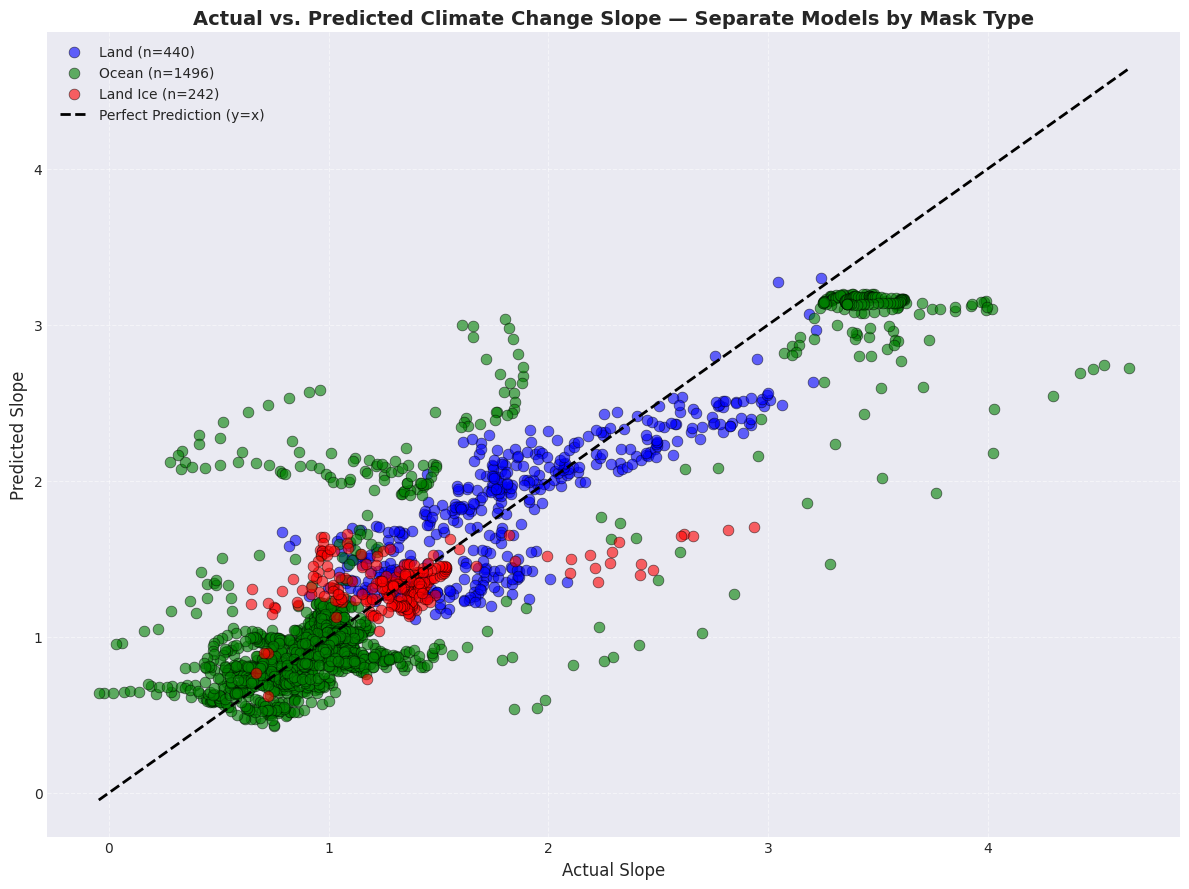

In [53]:

# Visualize: Actual vs Predicted Slopes, colored by mask type
plt.figure(figsize=(12, 9))

colors = {1: 'blue', 2: 'green', 3: 'red'}
labels = {1: 'Land', 2: 'Ocean', 3: 'Land Ice'}

for mask_val in available_masks:
    mask_name = labels.get(mask_val, f'Unknown ({mask_val})')
    mask_data = df_comparison[df_comparison['land_ocean_ice_mask'] == mask_val]
    mask_data = mask_data.dropna(subset=['Actual_Slope', 'Predicted_Slope'])
    
    if len(mask_data) > 0:
        plt.scatter(
            mask_data['Actual_Slope'], 
            mask_data['Predicted_Slope'],
            alpha=0.6, 
            color=colors.get(mask_val, 'gray'),
            s=60, 
            edgecolors='black', 
            linewidth=0.5,
            label=f"{mask_name} (n={len(mask_data)})"
        )

# Add perfect prediction line
all_data = df_comparison.dropna(subset=['Actual_Slope', 'Predicted_Slope'])
if len(all_data) > 0:
    min_val = min(all_data['Actual_Slope'].min(), all_data['Predicted_Slope'].min())
    max_val = max(all_data['Actual_Slope'].max(), all_data['Predicted_Slope'].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Actual vs. Predicted Climate Change Slope — Separate Models by Mask Type', fontsize=14, fontweight='bold')
plt.xlabel('Actual Slope', fontsize=12)
plt.ylabel('Predicted Slope', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [54]:
# Spatial Residual Map (simple rectangular grid visualization)
import folium
from branca.colormap import linear

map_data = df_comparison.copy()
required_cols = ['Predicted_Slope', 'Actual_Slope', 'lat_min', 'lat_max', 'lon_min', 'lon_max']
map_data_valid = map_data.dropna(subset=required_cols).copy()

if map_data_valid.empty:
    raise ValueError('No valid rows available for predicted slope map.')

value_min = float(map_data_valid['Predicted_Slope'].min())
value_max = float(map_data_valid['Predicted_Slope'].max())
colormap = linear.YlOrRd_09.scale(value_min, value_max)
colormap.caption = 'Predicted Climate Change Slope (Physical Model)'

predicted_slope_map = folium.Map(location=[20.0, 0.0], zoom_start=2, tiles='CartoDB positron')
for _, row in map_data_valid.iterrows():
    predicted_slope = float(row['Predicted_Slope'])
    popup_lines = [
        f"<b>Bounds:</b> [{row['lat_min']:.1f}, {row['lat_max']:.1f}) lat, [{row['lon_min']:.1f}, {row['lon_max']:.1f}) lon"
        , f"<b>Predicted Slope:</b> {predicted_slope:.6f}"
        , f"<b>Actual Slope:</b> {float(row['Actual_Slope']):.6f}" if pd.notna(row.get('Actual_Slope')) else '<b>Actual Slope:</b> N/A'
    ]
    popup_html = '<br>'.join(popup_lines)
    bounds = [[row['lat_min'], row['lon_min']], [row['lat_max'], row['lon_max']]]
    folium.Rectangle(bounds=bounds, stroke=False, fill=True, fill_color=colormap(predicted_slope), fill_opacity=0.7, popup=folium.Popup(popup_html, max_width=320)).add_to(predicted_slope_map)

colormap.add_to(predicted_slope_map)
map_output_path = os.path.join(OUTPUT_DIR, 'predicted_slopes_map_physical.html')
predicted_slope_map.save(map_output_path)
print(f'✓ Predicted slope map saved to: {map_output_path}')
predicted_slope_map

✓ Predicted slope map saved to: ./notebook_outputs/multilinear_physical/predicted_slopes_map_physical.html


In [35]:
# Save standardized predictions CSV
os.makedirs(OUTPUT_DIR, exist_ok=True)
prediction_cols = ['cell_id', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'station_count', 'Actual_Slope', 'Predicted_Slope', 'Residual']
available_prediction_cols = [c for c in prediction_cols if c in df_comparison.columns]
df_comparison[available_prediction_cols].to_csv(PREDICTIONS_CSV, index=False)
print(f'✓ Standardized predictions saved to: {PREDICTIONS_CSV}')

✓ Standardized predictions saved to: ./notebook_outputs/multilinear_physical/predictions_physical.csv
